In [1]:
import os
import random
import numpy as np
import pandas as pd 
import json
import matplotlib.pyplot as plt
from loguru import logger
import glob
from tqdm import tqdm

In [2]:
random.seed(123)
np.random.seed(123)

# Split data based on space groups

In [3]:
DATA_DIR = "/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2"

num_per_group = {}
for space_group in os.listdir(DATA_DIR):
    if space_group.endswith(".npy"):
        continue
    dir_name = os.path.join(DATA_DIR, space_group)
    num_per_group[space_group] = len(os.listdir(dir_name))

print("Target count per split train/val/test:",np.sum(list(num_per_group.values()))*0.8, np.sum(list(num_per_group.values()))*0.1, np.sum(list(num_per_group.values()))*0.1)

Target count per split train/val/test: 88183.20000000001 11022.900000000001 11022.900000000001


In [4]:
list_groups = list(num_per_group.keys())
choices = list(range(0,len(list_groups)))
np.random.shuffle(choices)
num_train = int(len(list_groups)*0.8)
num_val = int(len(list_groups)*0.1)
num_test = len(list_groups) - (num_train + num_val)

train_groups = choices[:num_train]
val_groups = choices[num_train:(num_train+num_val)]
test_groups = choices[(num_train+num_val):]
print(len(train_groups), len(val_groups), len(test_groups))

# Count number of tiles per group
cnt_train = 0
train_group_names = []
for g in train_groups:
    space_group = list_groups[g]
    train_group_names.append(space_group)
    dir_name = os.path.join(DATA_DIR, space_group)
    cnt_train += len(os.listdir(dir_name))

cnt_val = 0
val_group_names = []
for g in val_groups:
    space_group = list_groups[g]
    val_group_names.append(space_group)
    dir_name = os.path.join(DATA_DIR, space_group)
    cnt_val += len(os.listdir(dir_name))

cnt_test = 0
test_group_names = []
for g in test_groups:
    space_group = list_groups[g]
    test_group_names.append(space_group)
    dir_name = os.path.join(DATA_DIR, space_group)
    cnt_test += len(os.listdir(dir_name))

print("Actual number of samples for train/val/test:",cnt_train, cnt_val, cnt_test)

179 22 23
Actual number of samples for train/val/test: 84572 13213 12444


In [5]:
179+22+23, 84572+13213+12444

(224, 110229)

In [6]:
suffix = "108k"
nodata_val = -9999

# Enumerate and save in file all train/val/test files
train_out_path = os.path.join(DATA_DIR, f"train_{suffix}.npy")
train_filepaths = []
for g in tqdm(train_group_names):
    dir_name = os.path.join(DATA_DIR, g)
    for fn in os.listdir(dir_name):
        fp = os.path.join(dir_name, fn)
        train_filepaths.append(fp)
# with open(train_out_path, "wb") as f:
#     np.savez(f, fps=train_filepaths)


val_out_path = os.path.join(DATA_DIR, f"val_{suffix}.npy")
val_filepaths = []
for g in tqdm(val_group_names):
    dir_name = os.path.join(DATA_DIR, g)
    for fn in os.listdir(dir_name):
        fp = os.path.join(dir_name, fn)
        val_filepaths.append(fp)
# with open(val_out_path, "wb") as f:
#     np.savez(f, fps=val_filepaths)


test_out_path = os.path.join(DATA_DIR, f"test_{suffix}.npy")
test_filepaths = []
for g in tqdm(test_group_names):
    dir_name = os.path.join(DATA_DIR, g)
    for fn in os.listdir(dir_name):
        fp = os.path.join(dir_name, fn)
        test_filepaths.append(fp)
# with open(test_out_path, "wb") as f:
#     np.savez(f, fps=test_filepaths)
len(train_filepaths)+len(val_filepaths)+len(test_filepaths),len(train_filepaths),len(val_filepaths),len(test_filepaths), DATA_DIR

  0%|          | 0/179 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:00<00:00, 297.63it/s]


(110229,
 84572,
 13213,
 12444,
 '/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2')

## Load and resample

In [4]:
suffix = "108k"
train_out_path = os.path.join(DATA_DIR, f"train_{suffix}.npy")
with open(train_out_path, "rb") as f:
    train_filepaths = np.load(f)["fps"]
val_out_path = os.path.join(DATA_DIR, f"val_{suffix}.npy")
with open(val_out_path, "rb") as f:
    val_filepaths = np.load(f)["fps"]
test_out_path = os.path.join(DATA_DIR, f"test_{suffix}.npy")
with open(test_out_path, "rb") as f:
    test_filepaths = np.load(f)["fps"]

len(train_filepaths)+len(val_filepaths)+len(test_filepaths),len(train_filepaths),len(val_filepaths),len(test_filepaths), DATA_DIR

(110229,
 84572,
 13213,
 12444,
 '/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2')

In [8]:
# Compile results after running 04_script_filter_data.sh
# train_idxs = os.listdir("filtered_datanew/train")
# train_idxs = [int(i.split(".")[0]) for i in train_idxs]
# filtered_train_fps = list(np.array(train_filepaths)[train_idxs])

# train_out_path_new = os.path.join(DATA_DIR, f"train_{suffix}new.npy")
# with open(train_out_path_new, "wb") as f:
#     np.savez(f, fps=filtered_train_fps)

# print("train", len(train_idxs), train_idxs[:10], len(train_filepaths), len(filtered_train_fps))



# val_idxs = os.listdir("filtered_datanew/val")
# val_idxs = [int(i.split(".")[0]) for i in val_idxs]
# filtered_val_fps = list(np.array(val_filepaths)[val_idxs])

# val_out_path_new = os.path.join(DATA_DIR, f"val_{suffix}new.npy")
# with open(val_out_path_new, "wb") as f:
#     np.savez(f, fps=filtered_val_fps)

# print("val", len(val_idxs), val_idxs[:10], len(val_filepaths), len(filtered_val_fps))



# test_idxs = os.listdir("filtered_datanew/test")
# test_idxs = [int(i.split(".")[0]) for i in test_idxs]
# filtered_test_fps = list(np.array(test_filepaths)[test_idxs])

# test_out_path_new = os.path.join(DATA_DIR, f"test_{suffix}new.npy")
# with open(test_out_path_new, "wb") as f:
#     np.savez(f, fps=filtered_test_fps)

# print("test", len(test_idxs), test_idxs[:10], len(test_filepaths), len(filtered_test_fps))

train 82247 [0, 1, 10, 100, 1000, 10000, 10001, 10002, 10003, 10004] 84572 82247


8763

In [27]:
# fp = "/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2/b258/2528_T37QCU_02.npy"
# with open(fp, "rb") as f:
#     npzfile = np.load(f, allow_pickle=True)
#     feats_whole = npzfile["features"]
#     features = npzfile["features"][:512, :512]

# nodata_val = -9999
# feats_tmp = np.where(features==nodata_val, np.nanmax(features), features)
# feats_min = np.nanmin(feats_tmp)
# feats_tmp = np.where(features==nodata_val, feats_min, features)    # replace nodata values with minimum
# feats_tmp = np.where(np.isnan(feats_tmp), feats_min, feats_tmp)    # replace nan values with minimum
# feats_tmp = np.nan_to_num(feats_tmp, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
# feats_tmp = (feats_tmp - np.nanmin(feats_tmp)) / np.maximum((np.nanmax(feats_tmp) - np.nanmin(feats_tmp)), 1)

# image = feats_tmp.astype(np.float32)
# # all_data = np.concatenate((image, snowice_mask, water_mask, cloudshadow_mask, cloud_mask, sun_mask), axis=-1)
# # all_data = data_transforms(all_data)
# # all_data = all_data[:,:512, :512]   # only get upper left corner for val/test set
# # image = all_data[:6,:,:]

# features.shape, np.unique(features), np.unique(feats_tmp), image.shape, np.unique(feats_whole)

((512, 512, 6),
 array([-9999], dtype=int16),
 array([0.]),
 (512, 512, 6),
 array([-9999,  -866,  -855, ...,  5481,  5494,  5505], dtype=int16))

In [7]:

out_path = os.path.join(DATA_DIR, f"train_{suffix}.npy")
with open(out_path, "rb") as f:
    npzfile = np.load(f, allow_pickle=True)
    fps = npzfile["fps"]

# Split Data based on tile ID

In [8]:
DATA_DIR = "/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2"
space_groups = [i for i in list(os.listdir(DATA_DIR)) if not i.endswith(".npy")]
prefixes = []
num_samples = 0
for sg in space_groups:
    space_dir = os.path.join(DATA_DIR, sg)
    tiles = [f'{sg}/{i.split("_")[0]}_' for i in list(os.listdir(space_dir))]
    num_samples += len(tiles)
    tiles = np.unique(tiles)
    prefixes += list(tiles)
random.shuffle(prefixes)
print(f"num_samples: {num_samples}")

num_samples: 110229


In [9]:
train_fps, val_fps, test_fps = [], [], []
TARGET_TRAIN_LEN = num_samples*0.8
TARGET_VAL_LEN = num_samples*0.1
for pref in prefixes:
    fps = glob.glob(os.path.join(DATA_DIR, f"{pref}*.npy"))
    if len(train_fps) < TARGET_TRAIN_LEN:
        train_fps += fps 
    elif len(val_fps) < TARGET_VAL_LEN:
        val_fps += fps
    else:
        test_fps += fps
print(f"Actual number of samples (train/val/test): {len(train_fps)}, {len(val_fps)}, {len(test_fps)}")

Actual number of samples (train/val/test): 88202, 11032, 10995


In [10]:
# Check that there's no overlap in files
for f in train_fps:
    if f in val_fps:
        logger.error(f'val : {f}')
    if f in test_fps:
        logger.error(f'test : {f}')

for f in val_fps:
    if f in test_fps:
        logger.error(f'test : {f}')

In [11]:
suffix = "108krandom"
# Enumerate and save in file all train/val/test files
train_out_path = os.path.join(DATA_DIR, f"train_{suffix}.npy")
with open(train_out_path, "wb") as f:
    np.savez(f, fps=train_fps)


val_out_path = os.path.join(DATA_DIR, f"val_{suffix}.npy")
with open(val_out_path, "wb") as f:
    np.savez(f, fps=val_fps)


test_out_path = os.path.join(DATA_DIR, f"test_{suffix}.npy")
with open(test_out_path, "wb") as f:
    np.savez(f, fps=test_fps)

# Visualizations

In [7]:
fps[0], len(fps)

('/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera/b368/5914_T17WPN_00.npy',
 81680)

In [11]:
# for i in range(47629):
i=286
fp =fps[i]  # 286, 406, 402, 751

with open(fp, "rb") as f:
    npzfile = np.load(f)
    features = npzfile["features"]  # (512,512,6)
    snowice_mask = npzfile["snowice_mask"]
    water_mask = npzfile["water_mask"]  # (512,512)
    cloudshadow_mask = npzfile["cloudshadow_mask"]  # (512,512)
    cloud_mask = npzfile["cloud_mask"]  # (512,512)
    sun_mask = npzfile["sun_mask"]  # (512,512)
print(i, np.sum(water_mask))

286 0


In [12]:
nodata_val = -9999
feats_tmp = np.where(features==nodata_val, np.nanmax(features), features)
feats_min = np.nanmin(feats_tmp)
feats_tmp = np.where(features==nodata_val, feats_min, features)    # replace nodata values with minimum
feats_tmp = np.where(np.isnan(feats_tmp), feats_min, feats_tmp)    # replace nan values with minimum
feats_tmp = np.nan_to_num(feats_tmp, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
feats_tmp = (feats_tmp - np.nanmin(feats_tmp)) / np.maximum((np.nanmax(feats_tmp) - np.nanmin(feats_tmp)), 1)

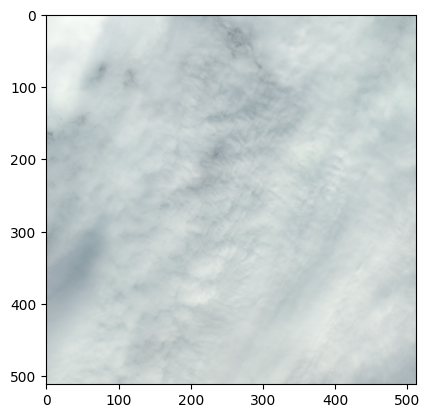

In [13]:
rgb = feats_tmp[:,:,:3][:,:,::-1]
plt.imshow(rgb)

(<matplotlib.image.AxesImage at 0x7f430c861a30>, array([0]))

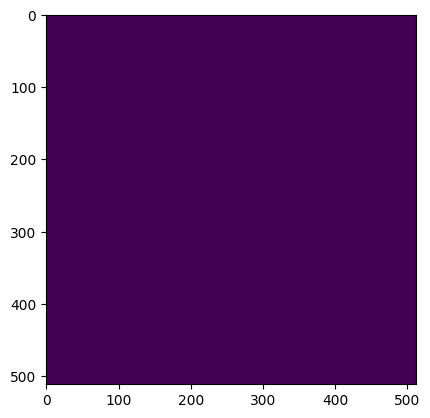

In [14]:
plt.imshow(water_mask), np.unique(water_mask)